In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

display(Markdown("## 📊 DATASET 4: WALMART SALES"))

df4 = pd.read_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\raw\walmart_sales\Walmart.csv")

print("Shape:", df4.shape)
df4.head()

## 📊 DATASET 4: WALMART SALES

Shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [2]:
display(Markdown("### 🔍 Step 1: Data Types & Structure"))
df4.info()

### 🔍 Step 1: Data Types & Structure

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [3]:
display(Markdown("### ⚠️ Step 2: Missing Values Check"))
print(df4.isnull().sum())

### ⚠️ Step 2: Missing Values Check

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [4]:
display(Markdown("### 🔁 Step 3: Duplicate Check"))
print("Duplicate rows:", df4.duplicated().sum())

### 🔁 Step 3: Duplicate Check

Duplicate rows: 0


In [5]:
display(Markdown("### 📈 Step 4: Summary Statistics"))
df4.describe()

### 📈 Step 4: Summary Statistics

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [6]:
display(Markdown("### ✅ Step 5: Validity Checks"))
print("Negative Weekly_Sales:", (df4['Weekly_Sales'] < 0).sum())
print("Negative Temperature:", (df4['Temperature'] < -50).sum())
print("Negative Fuel_Price:", (df4['Fuel_Price'] < 0).sum())
print("Holiday_Flag values:", df4['Holiday_Flag'].unique())
print("Unique Stores:", df4['Store'].nunique())
print("Date range:", df4['Date'].min(), "to", df4['Date'].max())

### ✅ Step 5: Validity Checks

Negative Weekly_Sales: 0
Negative Temperature: 0
Negative Fuel_Price: 0
Holiday_Flag values: [0 1]
Unique Stores: 45
Date range: 01-04-2011 to 31-12-2010


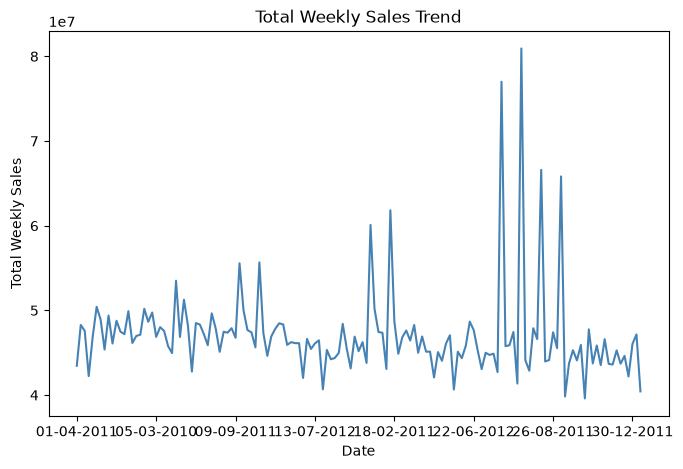

In [7]:
plt.figure(figsize=(8,5))
df4.groupby('Date')['Weekly_Sales'].sum().plot(color='steelblue')
plt.title('Total Weekly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.show()

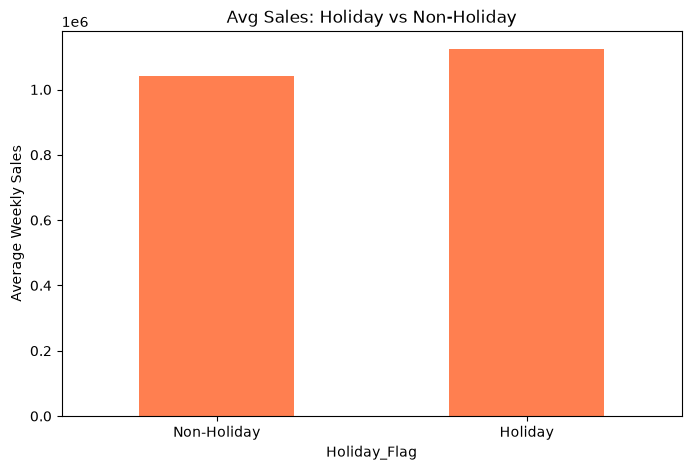

In [8]:
plt.figure(figsize=(8,5))
df4.groupby('Holiday_Flag')['Weekly_Sales'].mean().plot(kind='bar', color='coral')
plt.title('Avg Sales: Holiday vs Non-Holiday')
plt.xticks([0,1], ['Non-Holiday', 'Holiday'], rotation=0)
plt.ylabel('Average Weekly Sales')
plt.show()

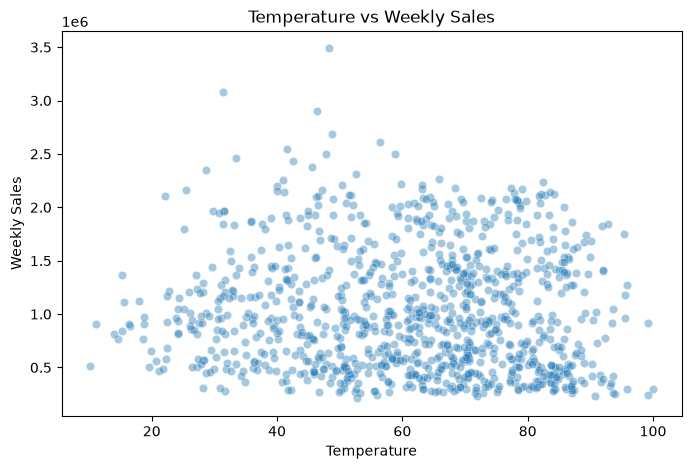

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df4.sample(1000), x='Temperature', y='Weekly_Sales', alpha=0.4)
plt.title('Temperature vs Weekly Sales')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.show()

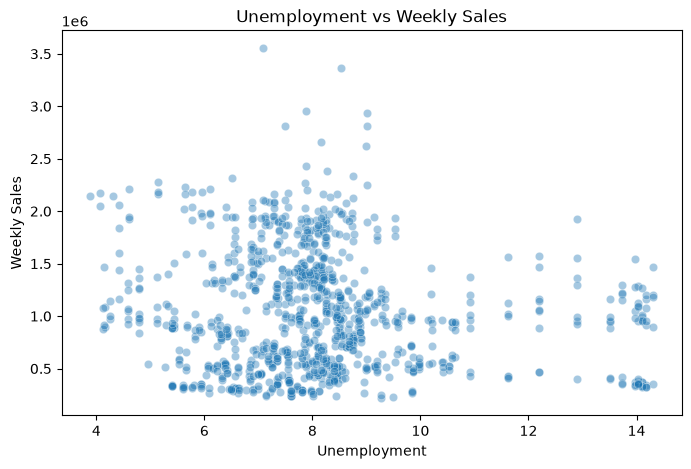

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df4.sample(1000), x='Unemployment', y='Weekly_Sales', alpha=0.4)
plt.title('Unemployment vs Weekly Sales')
plt.xlabel('Unemployment')
plt.ylabel('Weekly Sales')
plt.show()

### 🎨 Step 6: Visual EDA

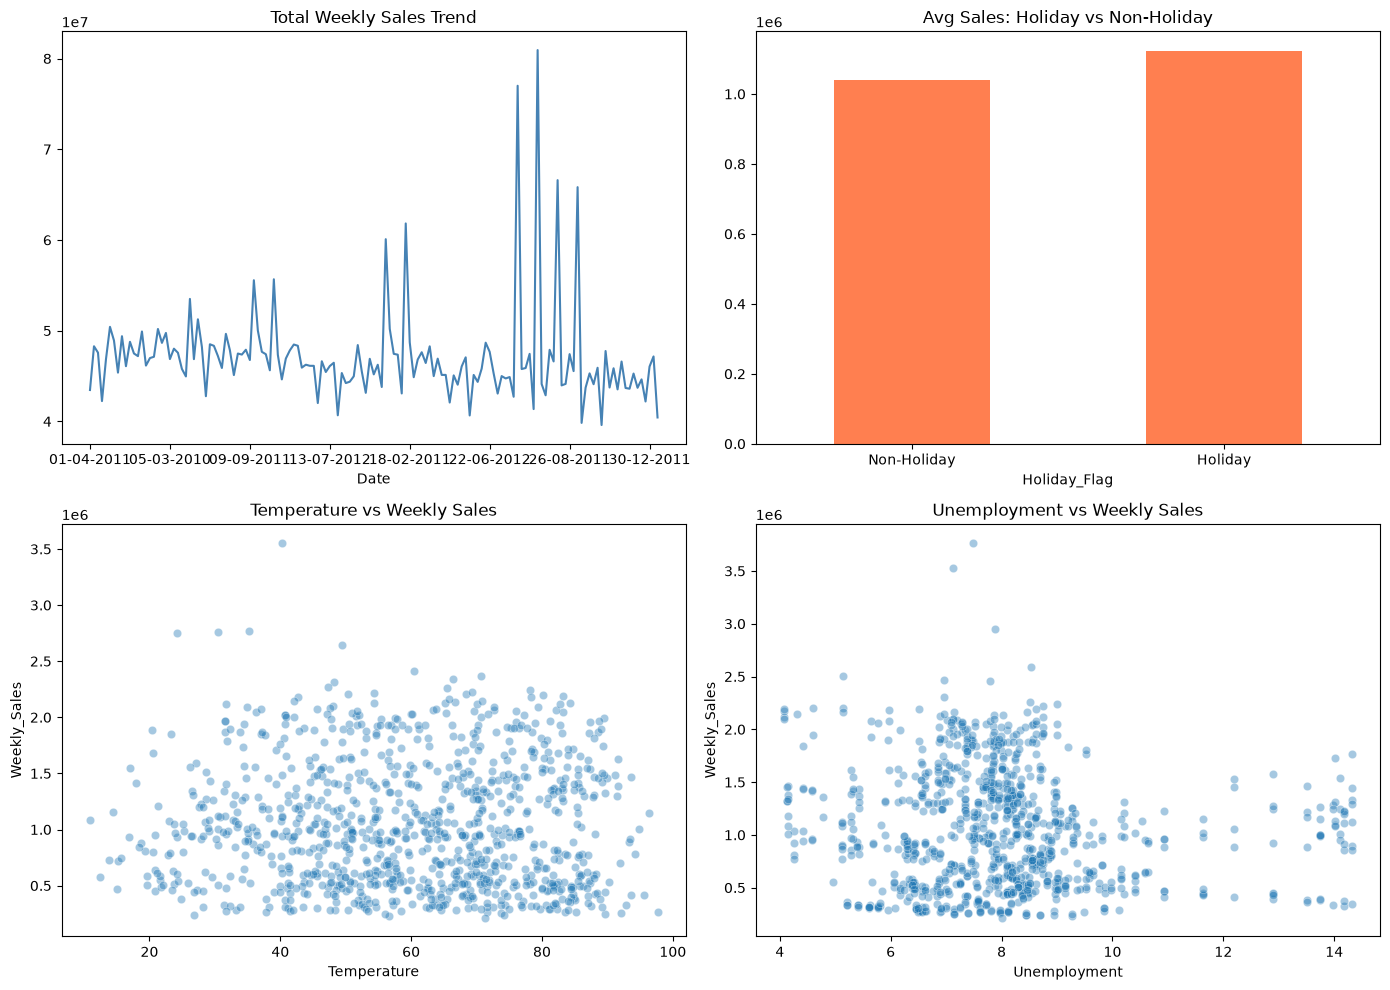

In [12]:
display(Markdown("### 🎨 Step 6: Visual EDA"))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df4.groupby('Date')['Weekly_Sales'].sum().plot(ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Weekly Sales Trend')

df4.groupby('Holiday_Flag')['Weekly_Sales'].mean().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Avg Sales: Holiday vs Non-Holiday')
axes[0,1].set_xticklabels(['Non-Holiday', 'Holiday'], rotation=0)

sns.scatterplot(data=df4.sample(1000), x='Temperature', y='Weekly_Sales', alpha=0.4, ax=axes[1,0])
axes[1,0].set_title('Temperature vs Weekly Sales')

sns.scatterplot(data=df4.sample(1000), x='Unemployment', y='Weekly_Sales', alpha=0.4, ax=axes[1,1])
axes[1,1].set_title('Unemployment vs Weekly Sales')

plt.tight_layout()
plt.show()

In [13]:
display(Markdown("### 🧹 Step 7: Data Cleaning"))

df4['Date'] = pd.to_datetime(df4['Date'], format='%d-%m-%Y')
df4.columns = df4.columns.str.lower()

print("Date column type:", df4['date'].dtype)
print("Corrected date range:", df4['date'].min(), "to", df4['date'].max())
print("\nColumns:", list(df4.columns))

### 🧹 Step 7: Data Cleaning

Date column type: datetime64[us]
Corrected date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00

Columns: ['store', 'date', 'weekly_sales', 'holiday_flag', 'temperature', 'fuel_price', 'cpi', 'unemployment']


In [14]:
display(Markdown("### 💾 Step 8: Save Cleaned Dataset"))

df4.to_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\processed_data\walmart_sales_clean.csv", index=False)

print("Saved successfully!")
print("Final shape:", df4.shape)

### 💾 Step 8: Save Cleaned Dataset

Saved successfully!
Final shape: (6435, 8)
